# (노트) 깁스샘플링
> 미완성

- toc:true
- branch: master
- badges: true
- comments: true
- author: 신록예찬
- categories: [통계계산]

### 예제1

`-` 주사위 2개를 던져서 확률변수 $X$와 $Y$를 아래와 같이 정의하자. 
- $X$: 첫번째 주사위의 던졌을때 나오는 숫자 ($X=1,2,3,4,5,6$)
- $Y$: 두 주사위의 합 ($Y=2,3,\dots,12$)

`-` $X,Y$의 확률질량함수는 아래와 같다. 

|$x$|1|2|3|4|5|6|
|:-:|:-:|:-:|:-:|:-:|:-:|:-:|
|$p(x)$|1/6|1/6|1/6|1/6|1/6|1/6|

|$y$|2|3|4|5|6|7|8|9|10|11|12|
|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|
|$p(x)$|1/36|2/36|3/36|4/36|5/36|6/36|5/36|4/36|3/36|2/36|1/36|

`-` 확률변수 $X$와 $Y$를 1000개씩 만들어보자. 아래와 같이 쉽게 할 수 있다. 

In [4]:
X=sample(1:6,size=10000,replace=T)
print(head(X))

[1] 2 5 5 4 5 5


In [5]:
Y=X+sample(1:6,size=10000,replace=T)
print(head(Y))

[1]  7 11  7  5 11  8


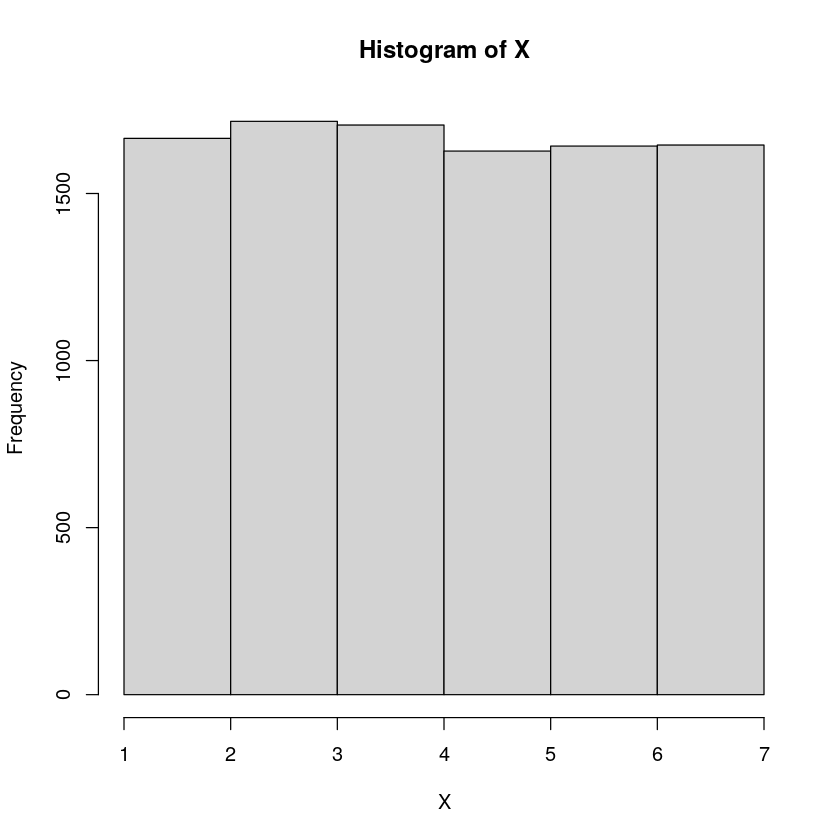

In [41]:
hist(X,1:7,right=F)

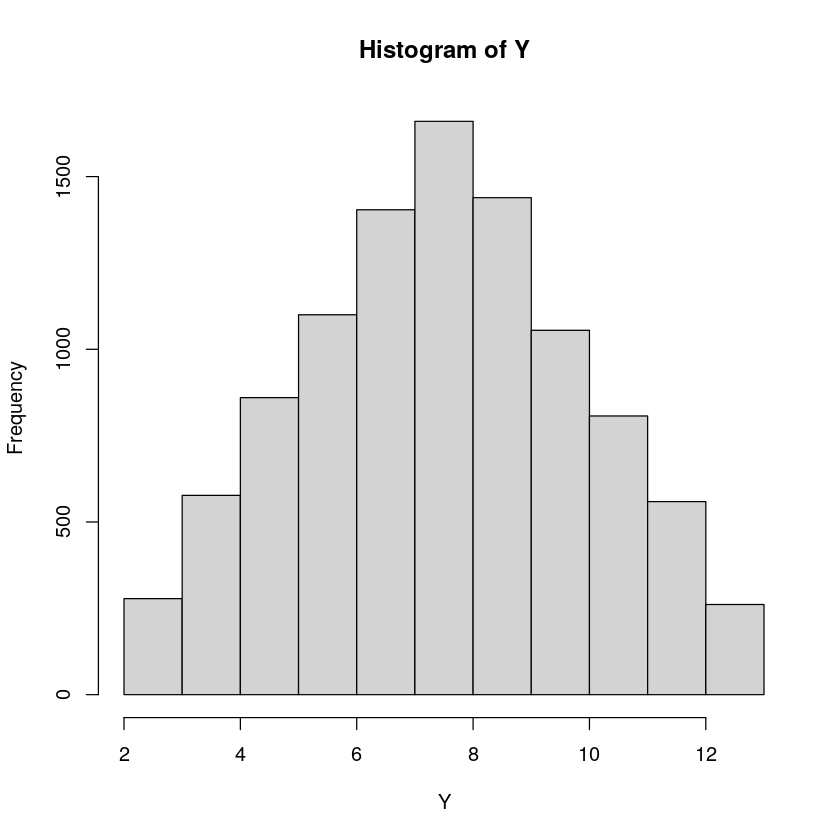

In [42]:
hist(Y,2:13,right=F)

`-` 그런데 잘 생각해보니까 $X$를 이미 얻었다면 $Y$는 $X$를 이용하여 쉽게 만들 수 있을 것 같다. 

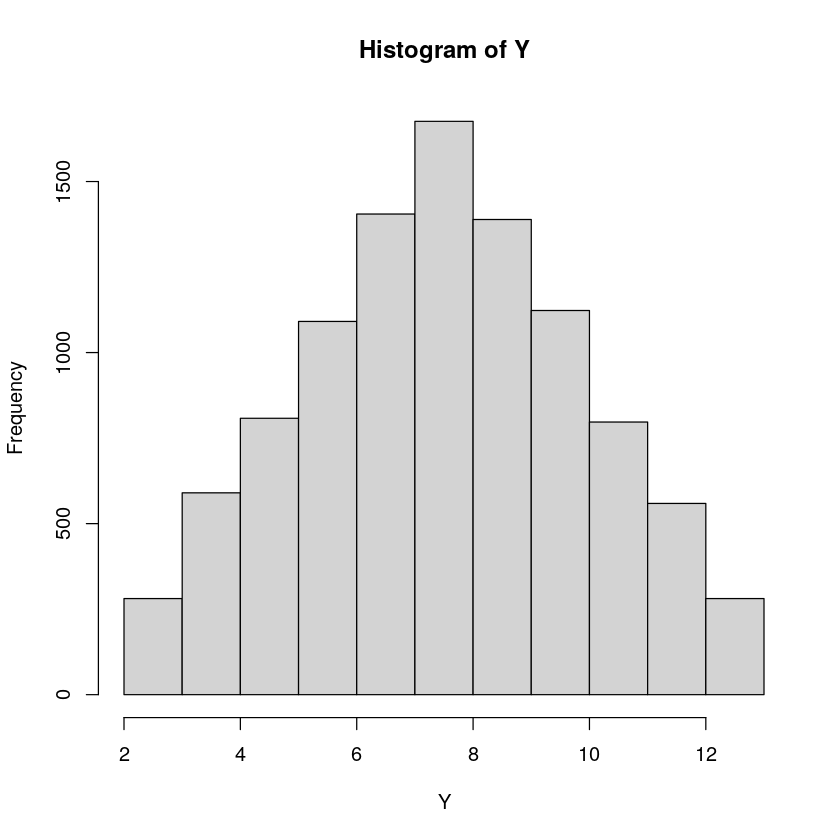

In [43]:
Y=X+sample(1:6,size=10000,replace=T)
hist(Y,breaks=2:13,right=F)

`-` 그렇다면 $Y=y$를 알고 있을때 $X$를 쉽게 얻을 수 있을까? 


- $P(X|Y=y)=?$

|y|X|
|:-:|:-:|
|2|1|
|3|1,2| 
|4|1,2,3| 
|5|1,2,3,4| 
|6|1,2,3,4,5| 
|7|1,2,3,4,5,6| 
|8|2,3,4,5,6| 
|9|3,4,5,6| 
|10|4,5,6| 
|11|5,6| 
|12|6| 

`-` 알 수 있다. 

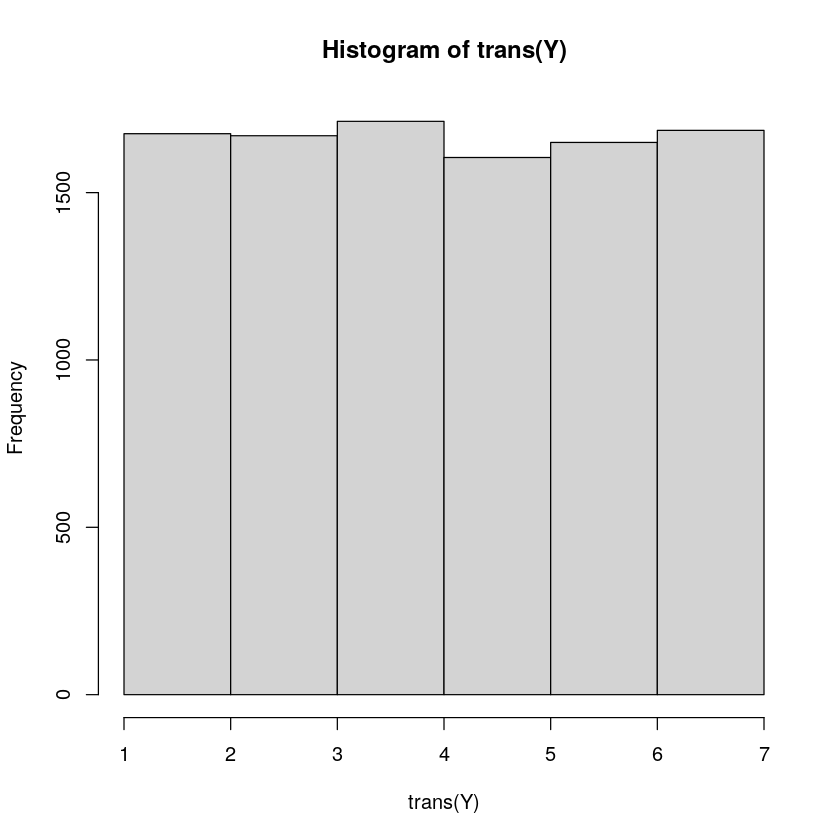

In [45]:
trans<-function(y){
    b<- y>=7 
    y-b*6
}
hist(trans(Y),breaks=1:7,right=F)

`-` 그렇다면 아래와 같이 샘플링 할 수도 있지 않을까? 
- $x_1$을 뽑는다. $x_1=random$
- 그걸 이용해 $y_1$ 추출. $y_1=x_1+random$
- 그걸 이용해 $x_2$ 추출. $x_2=trans(y_1)$
- 그걸 이용해 $y_2$ 추출. $y_2=x_2+random$
- 그걸 이용해 $x_3$ 추출. $x_3=trans(y_2)$
- 그걸 이용해 $y_3$ 추출. $y_2=x_3+random$
- 그걸 이용해 $x_4$ 추출. $x_4=trans(y_3)$

In [47]:
set.seed(3)
x<-c()
y<-c()
x[1]<-sample(1:6,size=1)
y[1]<-x[1]+sample(1:6,size=1)

In [48]:
print(x)

[1] 5


In [49]:
print(y)

[1] 7


In [50]:
x[2]<-trans(y[1])
y[2]<-x[2]+sample(1:6,size=1)

In [51]:
print(x)

[1] 5 1


In [52]:
print(y)

[1] 7 5


In [53]:
x[3]<-trans(y[2])
y[3]<-x[3]+sample(1:6,size=1)

In [54]:
print(x)

[1] 5 1 5


In [55]:
print(y)

[1] 7 5 9


In [56]:
x[4]<-trans(y[3])

In [57]:
print(x)

[1] 5 1 5 3


`-` random이 들어간것은 4개인데, 우리가 만든 변수는 7개이다. (나쁘지 않음) 

`-` $ x$가 살짝 중복되는 느낌도 있고, 이렇게 뽑아서 되는건가 싶은 느낌도 있음. 

`-` 많이 뽑아서 그려보자.

In [58]:
x<-c()
y<-c()
x[1]<-sample(1:6,size=1)
for(i in 1:10000){ 
    y[i]<-x[i]+sample(1:6,size=1)
    x[i+1]<-trans(y[i])
}

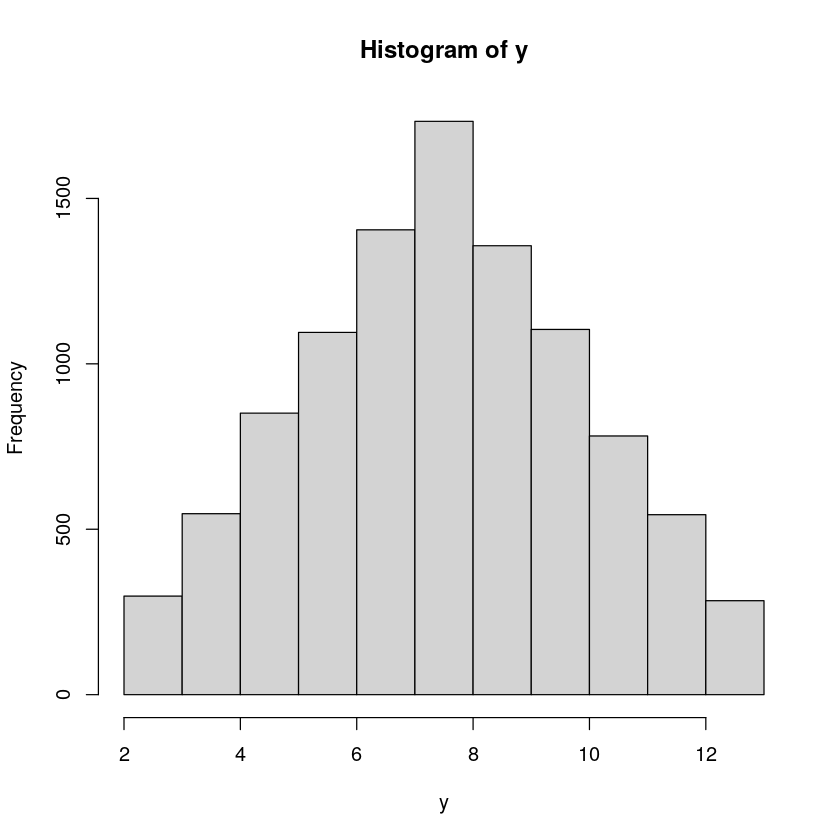

In [59]:
hist(y,breaks=2:13,right=F)

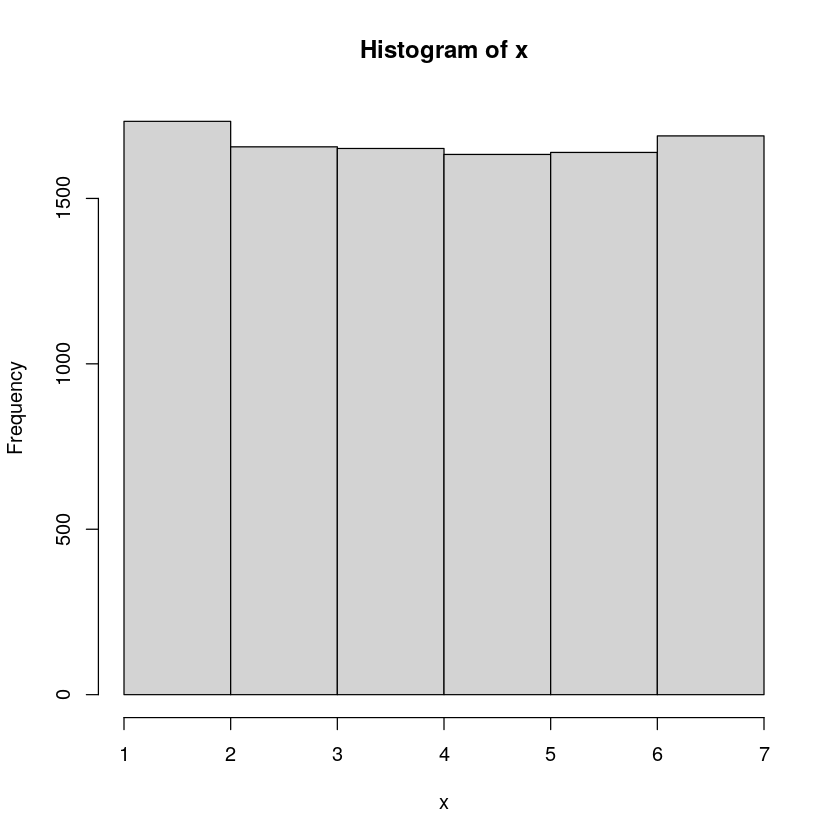

In [60]:
hist(x,breaks=1:7,right=F)

느낌

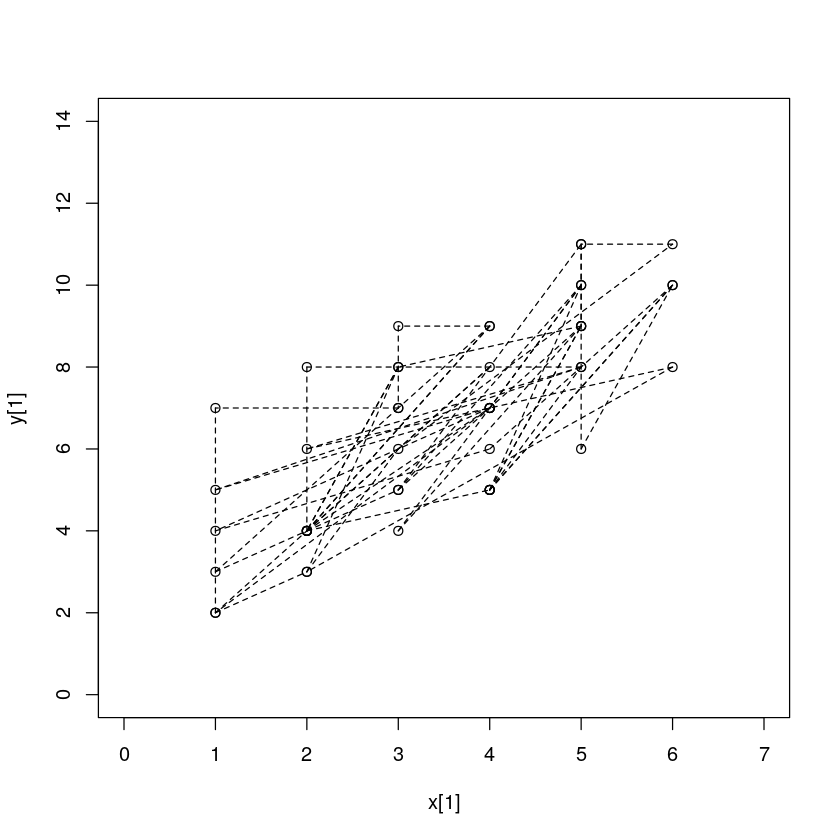

In [145]:
x<-c()
y<-c()
x[1]<-sample(1:6,size=1)
y[1]<-x[1]+sample(1:6,size=1)
x[2]<-trans(y[1])
plot(x[1],y[1],xlim=c(0,7),ylim=c(0,14))
for(i in 2:50){ 
    y[i]<-x[i]+sample(1:6,size=1)
    points(x[i],y[i])
    lines(c(x[i-1],x[i]),c(y[i-1],y[i]),lty=2)
    x[i+1]<-trans(y[i])
}

이것이 왜 가능한가? 

`-` $(X,Y)$의 확률질량함수를 $f(x,y)$라고 하자. 

`-` detailed balance condition을 만족하는지 따지자. 

- $p(x_{t+1},y_{t+1} | x_t, y_t)p(x_t,y_t) =p(x_t,y_t|x_{t+1},y_{t+1})p(x_{t+1},y_{t+1})$

그런데 아래가 성립한다. 

$$p(x_{t+1},y_{t+1}|x_t,y_t)=p(x_{t+1}|y_t)\times p(y_{t+1}|x_{t+1}) $$

$t,t+1$의 순서를 바꾸면 

$$p(x_{t},y_{t}|x_{t+1},y_{t+1})= p(x_{t}|y_{t+1})\times p(y_{t}|x_{t}) $$

각각 detail balance condition에 대입하면 

$p(x_{t+1}|y_t)\times p(y_{t+1}|x_{t+1}) \times p(x_t,y_t) =p(x_{t}|y_{t+1})\times p(y_{t}|x_{t})\times p(x_{t+1},y_{t+1})$